In [1]:
import os, sys
pgm_path = '../Code/ESCAPE_MAP_DRAFT/PGM/'

sys.path.append(pgm_path + 'source/')
sys.path.append(pgm_path + 'utilities/')
sys.path.append('../')

# imports
import utilities, Proteins_utils
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
aa = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y','-']
aa_id = {}
for id, a in enumerate(aa): aa_id[a]= id


q = 21
L = 178

BEGIN = 18
END = 5

WT_SEQ = Proteins_utils.load_FASTA("../Code/ESCAPE_MAP_DRAFT/seq_data/rbd_wt.fasta")[0]
WT_SEQ = WT_SEQ[BEGIN:-END]

/home/alessandro/Desktop/ENS/Regression/../Code/ESCAPE_MAP_DRAFT/PGM/source/numba_utilities.py:1124: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'F', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  dmean_v_dw = np.dot(s1.T, V)
/home/alessandro/Desktop/ENS/Regression/../Code/ESCAPE_MAP_DRAFT/PGM/source/numba_utilities.py:961: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'A', False, aligned=True))
  mean_V = np.dot(weights, V) / sum_weights


In [13]:
import matplotlib
import matplotlib.ticker as ticker
from tqdm import tqdm
import seaborn as sns
from sklearn.model_selection import train_test_split

plt.rc('font', size = 12)
plt.rc('xtick', labelsize = 11)
plt.rc('ytick', labelsize = 11)
plt.rc('legend', fontsize = 10)
plt.rc('axes', labelsize = 12)

# Importing data

In [2]:
exp_data_path = '../Code/ESCAPE_MAP_DRAFT/exp_data/'

escape_db=pd.read_csv('../Code/ESCAPE_MAP_DRAFT/exp_data/starr_nature/starr_nature_all_antibodies_raw_data.csv', sep=',')

ab_list=escape_db.condition.unique()
ab_list

array(['LY-CoV016', 'COV2-2050', 'COV2-2082', 'COV2-2094', 'COV2-2096',
       'COV2-2130', 'COV2-2165', 'COV2-2196', 'COV2-2479', 'COV2-2499',
       'COV2-2677', 'COV2-2832', 'CR3022', 'LY-CoV555', 'REGN10933',
       'REGN10987', 'S2D106', 'S2E12', 'S2H13', 'S2H14', 'S2H58', 'S2H97',
       'S2X16', 'S2X227', 'S2X259', 'S2X35', 'S2X58', 'S304', 'S309'],
      dtype=object)

In [ ]:
data = {}
for ab in ab_list:
    with open(exp_data_path+"starr_nature/DMS_"+ab+".csv", 'r') as file:
        line = file.readline().split(sep = ',')
        M = int(line[0])
        N = int(line[1])
        #print(M,N)

        delta = np.zeros((M,N),dtype = np.float32)
        G = np.zeros(M,dtype = np.float32)
        for m in range(M):
            line = file.readline().split(sep = ',')
            delta[m] = [int(line[i]) for i in range(N)]
            G[m] = float(line[-1])
    data[ab] = {'X': delta, 'y': G}

In [ ]:
for ab in ab_list:
    delta = data[ab]['X']
    M = delta.shape[0] 
    sequences = np.zeros((M,L),dtype = np.int16)
    for m,x in enumerate(delta):
        for site in range(L): 
            for a in range(q): 
                if x[site*q+a]: sequences[m,site] = a
    data[ab]['S'] = sequences 

In [35]:
WT_SEQ

array([15, 17, 19,  0, 18, 11, 14,  8, 14,  7, 15, 11,  1, 17,  0,  2, 19,
       15, 17,  9, 19, 11, 15,  0, 15,  4, 15, 16,  4,  8,  1, 19,  5, 17,
       15, 12, 16,  8,  9, 11,  2,  9,  1,  4, 16, 11, 17, 19,  0,  2, 15,
        4, 17,  7, 14,  5,  2,  3, 17, 14, 13,  7,  0, 12,  5, 13, 16,  5,
        8,  7,  0,  2, 19, 11, 19,  8,  9, 12,  2,  2,  4, 16,  5,  1, 17,
        7,  0, 18, 11, 15, 11, 11,  9,  2, 15,  8, 17,  5,  5, 11, 19, 11,
       19,  9, 19, 14,  9,  4, 14,  8, 15, 11,  9,  8, 12,  4,  3, 14,  2,
        7, 15, 16,  3,  7, 19, 13,  0,  5, 15, 16, 12,  1, 11,  5, 17,  3,
        5,  4, 11,  1, 19,  4, 12,  9, 13, 15, 19,  5,  4, 13, 12, 16, 11,
        5, 17,  5, 19, 13, 12, 19, 14, 17, 17, 17,  9, 15,  4,  3,  9,  9,
        6,  0, 12,  0, 16, 17,  1,  5], dtype=int16)

In [43]:
def find_mutated_sites(s, wt):
    muts = []
    for site, check in enumerate(s!=wt):
        if check: muts.append(site)
    return muts

In [ ]:
for ab in ['S2X16']:
    delta = data[ab]['X']
    G = data[ab]['y']
    S = data[ab]['S']
    mutations = -np.ones(M, dtype=np.int32)
    for m, s in enumerate(S):
        mutations[m] = find_mutated_sites(s, WT_SEQ)[0]
    data[ab]['Mutated sites'] = mutations

    site_variances = np.zeros(L,dtype = np.float32)
    for site in range(L):
        # Select sequences mutated at this site
        site_variances[site] = np.var(G[mutations == site])

        plt.plot()


IndexError: boolean index did not match indexed array along axis 0; size of axis is 1671 but size of corresponding boolean axis is 1673

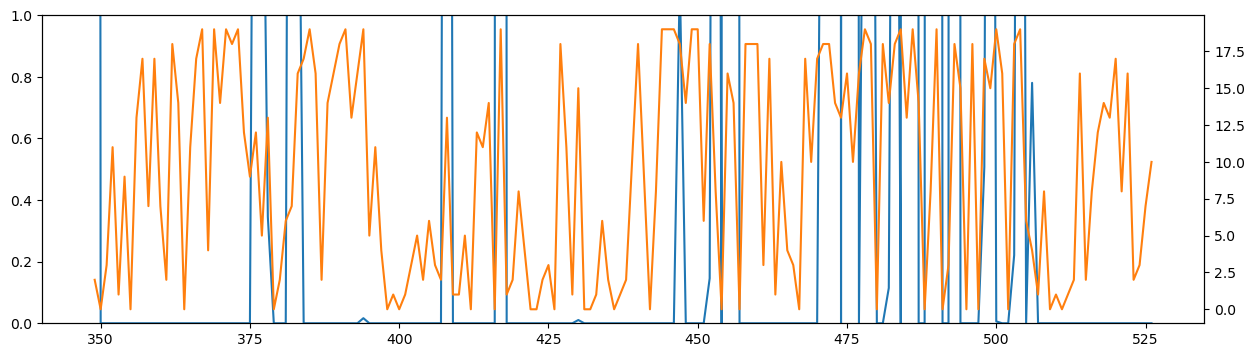

In [ ]:
ab = 'S2X16'
delta = data[ab]['X']
G = data[ab]['y']
S = data[ab]['S']
M = delta.shape[0] 
mutations = -np.ones(M, dtype=np.int32)
for m, s in enumerate(S):
    muts = find_mutated_sites(s, WT_SEQ)
    mutations[m] = muts[0] 
data[ab]['Mutated sites'] = mutations

site_variances = np.zeros(L,dtype = np.float32)
number_of_samples = np.zeros(L,dtype = np.int16)
for site in range(L):
    # Select sequences mutated at this site
    mask = mutations == site
    number_of_samples[site] = np.sum(mask)
    if mask.any() == False: site_variances[site] = 0
    else: site_variances[site] = np.var(G[mask]**2)

    if number_of_samples[site] > 5: 
        print


fig, ax = plt.subplots()
fig.set_figheight(4)
fig.set_figwidth(15)
ax.plot(range(349, 349+178), site_variances)
#ax.set_yscale("log")
#ax.set_ylim(0,1)
#ax.set_ylim(0.00001,100)
ax1 = ax.twinx()
ax1.plot(range(349, 349+178), number_of_samples, c = 'C1')

In [ ]:
def ridge_regression(X, y, lam):
    """
    Ridge regression with intercept (intercept is not penalised).

    Parameters
    ----------
    X   : array of shape (n, p)
    y   : array of shape (n,)
    lam : regularisation strength (lambda)

    Returns
    -------
    intercept : float
    coefs     : array of shape (p,)
    """
    n, p = X.shape

    # 1. Augment X with a leading column of ones
    ones = np.ones((n, 1))
    X_tilde = np.hstack([ones, X])          # shape (n, p+1)

    # 2. Build the regularisation matrix (do NOT penalise the intercept)
    Lambda = lam * np.eye(p + 1)
    Lambda[0, 0] = 0.0                      # zero out the intercept penalty

    # 3. Closed-form ridge solution: (X̃ᵀX̃ + Λ)⁻¹ X̃ᵀy
    A = X_tilde.T @ X_tilde + Lambda
    beta = np.linalg.solve(A, X_tilde.T @ y)

    intercept = beta[0]
    coefs     = beta[1:]
    return intercept, coefs




In [165]:
from sklearn.linear_model import Ridge

In [11]:
def ridge_regression_stable(delta, G, lam):
    n, p = delta.shape

    delta_mean = np.mean(delta, axis=0)
    X = delta - delta_mean[None, :]

    G_mean = np.mean(G)
    y = G - G_mean

    # SVD of X (not X.T @ X) — avoids squaring the condition number
    U, s, Vt = np.linalg.svd(X, full_matrices=False)

    # Ridge solution: V @ diag(s / (s² + n*lam)) @ U.T @ y
    d = s / (s**2 + n * lam)
    g_hat = Vt.T @ (d * (U.T @ y))

    return g_hat, delta_mean, G_mean


In [4]:
def ridge_regression(delta, G, lam):

    n, p = delta.shape

    delta_mean = np.mean(delta, axis = 0)

    X = delta - delta_mean[None,:]

    G_mean = np.mean(G)

    y = G - G_mean

    #lr=Ridge(alpha=lam*n, fit_intercept = False)

    #lr.fit(X, y)
    #g_hat = lr.coef_
    
    g_hat = np.linalg.solve(X.T@X + n * lam * np.eye(p), X.T @ y)

    return g_hat, delta_mean, G_mean

def ridge_regression_sk(delta, G, lam):

    n, p = delta.shape

    lr=Ridge(alpha=lam*n)

    lr.fit(delta, G)
    intercept = lr.intercept_ 
    g_hat = lr.coef_
    #g_hat = np.linalg.solve(X.T@X + n * lam * np.eye(p), X.T @ y)

    return g_hat, intercept

In [55]:
exp_data_path = '../Code/ESCAPE_MAP_DRAFT/exp_data/'
q = 20
AB = 'S2X16'
with open(exp_data_path+"starr_nature/DMS_"+AB+".csv", 'r') as file:
    line = file.readline().split(sep = ',')
    M = int(line[0])
    N = int(line[1])
    print(M,N)

    delta = np.zeros((M,N),dtype = np.float32)
    G = np.zeros(M,dtype = np.float64)
    for m in range(M):
        line = file.readline().split(sep = ',')
        delta[m] = [int(line[i]) for i in range(N)]
        G[m] = float(line[-1])
        
# remove gap (and WT)
def get_cols_to_remove(L, q, WT):
    cols = set()
    for site in range(L):
        base = site * (q+1)
        cols.add(base + q )       # ultima feature del sito
        #cols.add(base + WT[site])     # feature wild-type del sito
    return sorted(cols)

cols_to_remove = get_cols_to_remove(L, q, WT_SEQ)
cols_to_keep   = [i for i in range(N) if i not in set(cols_to_remove)]

delta_new = delta[:, cols_to_keep]
print(f"Shape originale: {delta.shape}")
print(f"Colonne rimosse: {len(cols_to_remove)}")
print(f"Shape finale:    {delta_new.shape}") 
delta = delta_new.copy()

1672 3738
Shape originale: (1672, 3738)
Colonne rimosse: 178
Shape finale:    (1672, 3560)


In [ ]:
n_trials = 100

split_fractions = [0.55]#[0.975]# np.linspace(0.05, 0.95, 10) #[0.05,0.15,0.25,0.35,0.45,0.55,0.65,0.75,0.85,0.95,0.975]
mu_grid = np.logspace(-7, 0, 8, endpoint=True) 
r_values = np.zeros(len(split_fractions))
risk_values = np.zeros((len(split_fractions), len(mu_grid), n_trials))

from tqdm import tqdm

for i, f in enumerate(split_fractions):

    print(i)

    for j, mu in enumerate(mu_grid):

        for trial in tqdm(range(n_trials)):

            delta_train, delta_test, G_train, G_test = train_test_split(delta, G, test_size=f)

            if j == 0 and trial == 0: r_values[i] = q * L / len(G_train)

            if mu < 5*10**(-8): g_hat, delta_mean, G_mean  = ridge_regression_stable(delta_train, G_train, mu)
            else: g_hat, delta_mean, G_mean  = ridge_regression(delta_train, G_train, mu)
            X_test = delta_test - delta_mean[None,:]
            G_pred = X_test @ g_hat + G_mean
            risk_values[i,j,trial] = np.mean((G_pred-G_test)**2)
        print(np.mean(risk_values[i,j,:]))

avg_risk = np.mean(risk_values  , axis = 2)
std_risk = np.std(risk_values, axis = 2)/np.sqrt(n_trials)      

0


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [01:00<00:00,  1.20s/it]


0.4449455605356041


100%|██████████| 50/50 [01:10<00:00,  1.42s/it]


...

0.839057465611025


100%|██████████| 50/50 [01:02<00:00,  1.26s/it]


1.5561033995319398


100%|██████████| 50/50 [01:01<00:00,  1.23s/it]

1.7382047637540978


In [126]:
risk_values

array([[[0.49508707, 0.50859986, 0.40989949, 0.38137476, 0.44475474,
         0.4156402 , 0.39264889, 0.44950141, 0.53761364, 0.44438876,
         0.40943486, 0.40484875, 0.52455365, 0.43775472, 0.37492019,
         0.46857263, 0.4314039 , 0.42413479, 0.42997845, 0.49142446,
         0.38436223, 0.40142961, 0.4699451 , 0.54649426, 0.37435802,
         0.45390557, 0.39565402, 0.46703617, 0.62990531, 0.46489686,
         0.41298729, 0.40662516, 0.40533262, 0.54331382, 0.4468093 ,
         0.47487076, 0.41575106, 0.45129912, 0.43552717, 0.38593004,
         0.43387063, 0.45075088, 0.47111582, 0.42127203, 0.45128794,
         0.41295893, 0.42580722, 0.52738879, 0.39924209, 0.41061501,
                nan,        nan,        nan,        nan,        nan,
                nan,        nan,        nan,        nan,        nan,
                nan,        nan,        nan,        nan,        nan,
                nan,        nan,        nan,        nan,        nan,
                nan,        nan,  

In [127]:
n_trials = 100

split_fractions = [0.55]#[0.975]# np.linspace(0.05, 0.95, 10) #[0.05,0.15,0.25,0.35,0.45,0.55,0.65,0.75,0.85,0.95,0.975]
mu_grid = np.logspace(-7, 0, 8, endpoint=True) 
r_values = np.zeros(len(split_fractions))
#risk_values = np.zeros((len(split_fractions), len(mu_grid), n_trials))
risk_values_old = risk_values.copy() 
risk_values = np.zeros((len(split_fractions), len(mu_grid), n_trials)) 
for i in range(risk_values_old.shape[0]):
    for j in range(risk_values_old.shape[1]):
        for trial in range(risk_values_old.shape[2]):
            risk_values[i,j,trial] = risk_values_old[i,j,trial]

from tqdm import tqdm

for i, f in enumerate(split_fractions):

    print(i)

    for j, mu in enumerate(mu_grid):

        for trial in tqdm(range(n_trials)):

            if risk_values[i,j,trial] > 0: continue
            else:

                delta_train, delta_test, G_train, G_test = train_test_split(delta, G, test_size=f)

                if j == 0 and trial == 0: r_values[i] = q * L / len(G_train)

                if mu < 5*10**(-8): g_hat, delta_mean, G_mean  = ridge_regression_stable(delta_train, G_train, mu)
                else: g_hat, delta_mean, G_mean  = ridge_regression(delta_train, G_train, mu)
                X_test = delta_test - delta_mean[None,:]
                G_pred = X_test @ g_hat + G_mean
                risk_values[i,j,trial] = np.mean((G_pred-G_test)**2)
        print(np.mean(risk_values[i,j,:]))

avg_risk = np.mean(risk_values  , axis = 2)
std_risk = np.std(risk_values, axis = 2)/np.sqrt(n_trials)      

0


100%|██████████| 100/100 [01:14<00:00,  1.34it/s]


0.4506571849008465


100%|██████████| 100/100 [01:11<00:00,  1.40it/s]


0.4595354852729357


...

0.8434349866214113


100%|██████████| 100/100 [01:09<00:00,  1.44it/s]


1.5477354241004184


100%|██████████| 100/100 [01:07<00:00,  1.47it/s]

1.7468195707052254


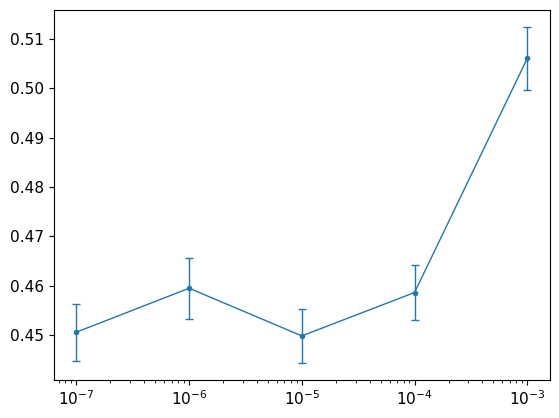

In [129]:
plt.errorbar(mu_grid[:5], avg_risk[0,:5], yerr = std_risk[0,:5],marker = "o", capsize  =  3, markersize = 3, linewidth = 1, elinewidth=1)
plt.xscale("log")

In [57]:
data = pd.DataFrame({'Ab': [],'q':[], 'L': [], 'M': [], 'r': [], 'mu': [], 'R': [], 'sR': [],'nTest': [],'nTrial': []}) 

In [88]:
AB = 'S2X16'
for j, mu in enumerate(mu_grid):
    for i, r in enumerate(r_values):
        data = pd.concat([data, pd.DataFrame({'Ab': [AB],'q':[q], 'L': [L], 'M': [int(q*L/r)], 'r': [r], 'mu': [mu], 'R': [avg_risk[i,j]], 'sR': [std_risk[i,j]],'nTest': [int(split_fractions[i]*len(G))],'nTrial': [n_trials]})])

In [89]:
outfile = "risk_"+AB+".csv"
data.to_csv(outfile, index = False)

In [90]:
outfile = "risk_"+AB+".csv"
data = pd.read_csv(outfile)
data

,Ab,q,L,M,r,mu,R,sR,nTest,nTrial
0,S2X16,20.0,178.0,1588.0,2.241814,1.000000e-09,0.310211,0.048023,83.0,10.0
1,S2X16,20.0,178.0,1421.0,2.505278,1.000000e-09,0.382656,0.023392,250.0,10.0
2,S2X16,20.0,178.0,1254.0,2.838915,1.000000e-09,0.411062,0.023064,418.0,10.0
3,S2X16,20.0,178.0,1086.0,3.278085,1.000000e-09,0.436110,0.011745,585.0,10.0
4,S2X16,20.0,178.0,919.0,3.873776,1.000000e-09,0.459417,0.024675,752.0,10.0
...,...,...,...,...,...,...,...,...,...,...
116,S2X16,20.0,178.0,585.0,6.085470,1.000000e-01,1.489819,0.016377,1086.0,10.0
117,S2X16,20.0,178.0,418.0,8.516746,1.000000e-01,1.555602,0.022985,1254.0,10.0
118,S2X16,20.0,178.0,250.0,14.240000,1.000000e-01,1.549547,0.023052,1421.0,10.0
119,S2X16,20.0,178.0,83.0,42.891566,1.000000e-01,1.597898,0.021447,1588.0,10.0


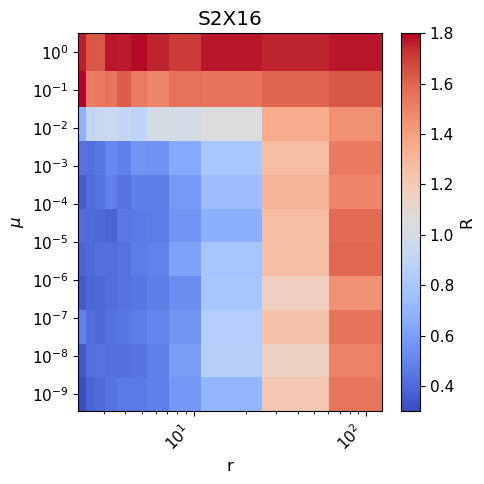

In [92]:


fig, ax = plt.subplots(1, 1)
fig.set_figheight(5)
fig.set_figwidth(5)

AB = "S2X16"
temp = data[(data['Ab'] == AB)]

pivot = temp.pivot(index='mu', columns='r', values='R')
densities = pivot.columns.values  # mu
temps = pivot.index.values        # r
Z = pivot.values

# Edges in log space
log_d = np.log10(densities)
x_edges = 10**np.concatenate((
    [log_d[0] - (log_d[1] - log_d[0]) / 2],
    (log_d[:-1] + log_d[1:]) / 2,
    [log_d[-1] + (log_d[-1] - log_d[-2]) / 2]
))

log_t = np.log10(temps)
y_edges = 10**np.concatenate((
    [log_t[0] - (log_t[1] - log_t[0]) / 2],
    (log_t[:-1] + log_t[1:]) / 2,
    [log_t[-1] + (log_t[-1] - log_t[-2]) / 2]
))

im = ax.pcolormesh(x_edges, y_edges, Z, cmap='coolwarm',
                   shading='auto', vmin=0.3, vmax=1.8)

ax.set_xscale('log')
ax.set_yscale('log')

# Let matplotlib pick clean log ticks automatically
ax.xaxis.set_major_locator(ticker.LogLocator(base=10, numticks=10))
ax.xaxis.set_major_formatter(ticker.LogFormatterSciNotation())
ax.yaxis.set_major_locator(ticker.LogLocator(base=10, numticks=12))
ax.yaxis.set_major_formatter(ticker.LogFormatterSciNotation())

# Remove minor ticks clutter
#ax.xaxis.set_minor_locator(ticker.NullLocator())
#ax.yaxis.set_minor_locator(ticker.NullLocator())

plt.xticks(rotation=45, ha='right')

plt.colorbar(im, ax=ax, label='R')
ax.set_title(AB)
ax.set_xlabel('r')
ax.set_ylabel('$\\mu$')

plt.tight_layout()
plt.show()

In [138]:
mu_opt = []
smu_opt = []
mu_max = []
mu_min = []
R_opt = []
r_values = []

for id, temp in data.groupby("r"):

    id_opt = np.argmin(temp['R'].values)
    row_opt = temp.iloc[id_opt] 
    R_opt_temp = row_opt['R']
    sR_opt_temp = row_opt['sR']
    mus = []
    for row_id, row in temp.iterrows(): 
        if row['R'] - R_opt_temp < np.sqrt(sR_opt_temp**2+row['sR']**2): mus.append(row['mu'])

    mu_opt.append(row_opt['mu'])
    smu_opt.append(np.std(mus))
    mu_min.append(np.min(mus)) 
    mu_max.append(np.max(mus)) 
    R_opt.append(row_opt['R'])
    r_values.append(row_opt['r'])

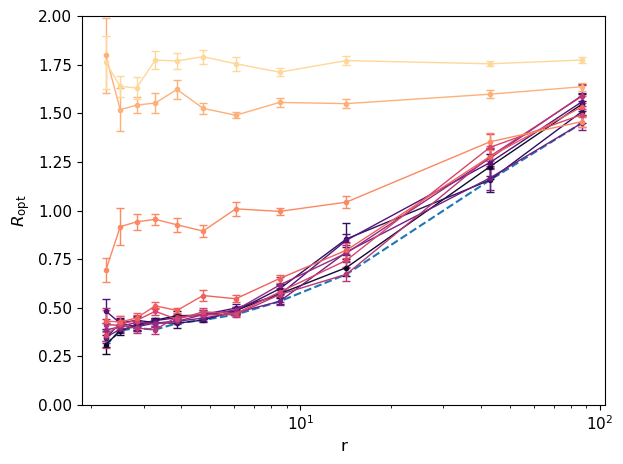

In [134]:
colors = sns.color_palette("magma", len(data['mu'].unique()))
i = -1
for id, temp in data.sort_values(by = 'mu').groupby("mu"):
    i += 1
    temp.sort_values(by = 'r', inplace=True)
    plt.errorbar(temp['r'], temp['R'], yerr = temp['sR'], marker = "o", capsize  =  3, markersize = 3, linewidth = 1, elinewidth=1,label = f"$\\mu = {id}$", c = colors[i])

plt.plot(r_values, R_opt, linestyle = '--')
plt.ylim(0,2)
plt.xscale("log")
plt.xlabel("r")
plt.ylabel('$R_{\\text{opt}}$')
plt.tight_layout()
plt.show()

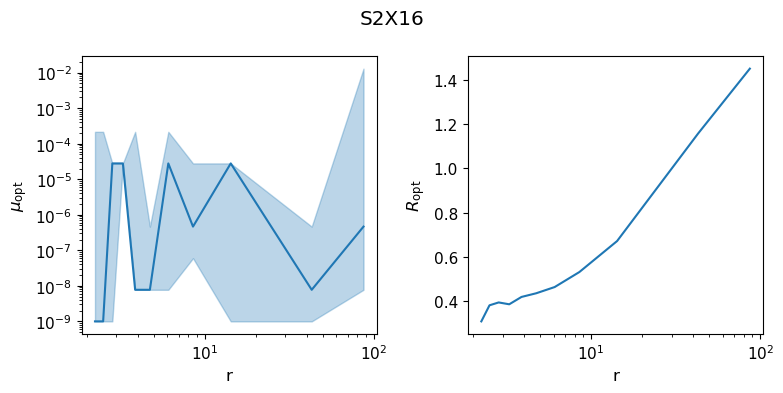

In [141]:
fig, [ax1, ax2] = plt.subplots(1,2) 
fig.set_figheight(4)
fig.set_figwidth(8)

fig.suptitle(AB)

#ax1.errorbar(r_values, mu_opt, smu_opt)
ax1.plot(r_values, mu_opt)
ax1.fill_between(r_values, mu_min, mu_max, alpha = 0.3, color = 'C0')

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("r")
ax1.set_ylabel('$\\mu_{\\text{opt}}$')

"""colors = sns.color_palette("magma", len(mu_grid))
i = -1
for id, temp in data.groupby("mu"):
    i += 1
    ax2.errorbar(temp['r'], temp['R'], yerr = temp['sR'], marker = "o", capsize  =  3, markersize = 3, linewidth = 1, elinewidth=1,label = f"$\\mu = {id}$", c = colors[i])"""

ax2.plot(r_values, R_opt)
ax2.set_xscale("log")
ax2.set_xlabel("r")
ax2.set_ylabel('$R_{\\text{opt}}$')

plt.tight_layout()
plt.show()

In [101]:
mu_values = []
Rmin_values = [] 

for id, temp in data.sort_values(by = 'mu').groupby("mu"):
    temp = temp[temp['r']<5]
    Rmin = np.sum(temp['R']*temp['sR']**2)/np.sum(temp['sR']**2)
    mu_values.append(id)
    Rmin_values.append(Rmin)

0.2113443019045801


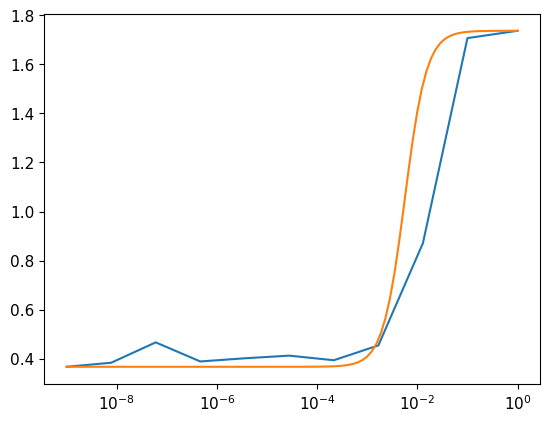

In [116]:
mu_values = np.array(mu_values)
Rmin_values = np.array(Rmin_values)

plt.plot(mu_values, Rmin_values)

R0 = np.min(Rmin_values)
SNR = Rmin_values[-1]*(1+(L*mu_values[-1])**2)/(L*mu_values[-1])**2-R0 
Fmis = R0/(R0+SNR)
print(Fmis)

mus = np.geomspace(10**(-9),1,100)
plt.plot(mus,R0+SNR*(L*mus)**2/(1+(L*mus)**2))
plt.xscale("log")

## Piccolo check

In [252]:
exp_data_path = '../Code/ESCAPE_MAP_DRAFT/exp_data/'
q = 20
with open(exp_data_path+"starr_nature/DMS_"+AB+".csv", 'r') as file:
    line = file.readline().split(sep = ',')
    M = int(line[0])
    N = int(line[1])

    delta = np.zeros((M,N),dtype = np.float32)
    G = np.zeros(M,dtype = np.float64)
    for m in range(M):
        line = file.readline().split(sep = ',')
        delta[m] = [int(line[i]) for i in range(N)]
        G[m] = float(line[-1])
    # remove gap       
    cols_to_remove = get_cols_to_remove(L, q, WT_SEQ)
    cols_to_keep   = [i for i in range(N) if i not in set(cols_to_remove)]

    delta_new = delta[:, cols_to_keep]
    delta = delta_new.copy()    

In [279]:
g, delta_mean, G_mean = ridge_regression(delta, G, 10**(-4)) 


In [280]:
g

array([ 0.        ,  0.        ,  0.        , ..., -0.03249184,
        0.        ,  0.        ], shape=(3560,))

In [281]:
g_matrix = g.reshape((len(g)//q, q)) 

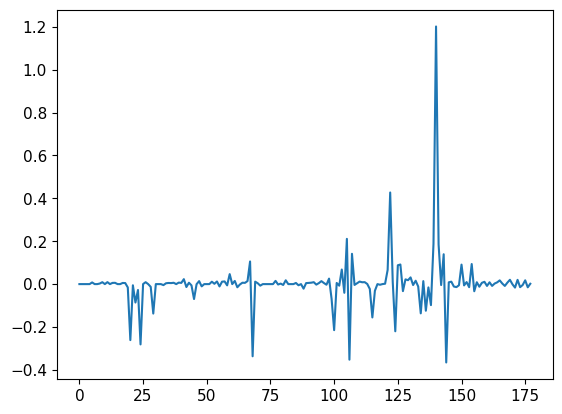

In [285]:
plt.plot(np.mean(g_matrix, axis = 1))

In [274]:
L,q = g_matrix.shape
for site in range(L):
    g_matrix[site,:] -= (np.sum(g_matrix[site,:])-g_matrix[site, WT_SEQ[site]])/(q-1)

In [275]:
norm = np.sum(g_matrix**2)
print(norm)
F = np.sum([g_matrix[site,WT_SEQ[site]]**2 for site in range(L)])/norm
print(F)

932.1161268882338
0.08268488310361792


In [287]:
norms = []
Fs = []
for mu in mu_grid:
    print(mu) 
    g, delta_mean, G_mean = ridge_regression(delta, G, mu) 
    g_matrix = g.reshape((len(g)//q, q)) 
    L,q = g_matrix.shape
    for site in range(L):
        g_matrix[site,:] -= (np.sum(g_matrix[site,:])-g_matrix[site, WT_SEQ[site]])/(q-1)
    norm = np.sum(g_matrix**2)
    F = np.sum([g_matrix[site,WT_SEQ[site]]**2 for site in range(L)])/norm
    norms.append(norm)
    Fs.append(F)

1e-07
1e-06
1e-05
0.0001
0.001
0.01
0.1


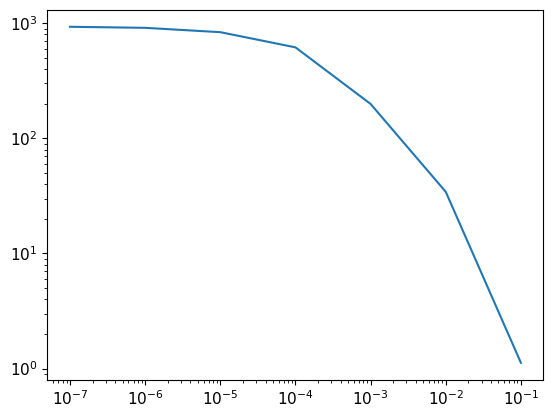

In [290]:
plt.plot(mu_grid, norms)
plt.xscale("log")
plt.yscale("log")

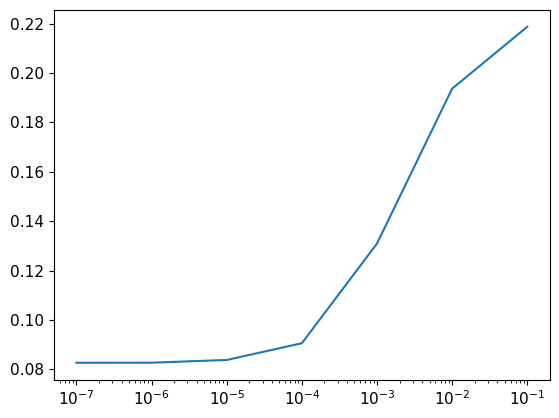

In [291]:
plt.plot(mu_grid, Fs)
plt.xscale("log")

# All antibodies

In [ ]:
exp_data_path = '../Code/ESCAPE_MAP_DRAFT/exp_data/'
outfile = "risk_data.csv"

n_trials = 10
q = 20 
L = len(WT_SEQ)

split_fractions =np.linspace(0.05,0.95,10)
mu_grid = np.logspace(-7, -1, 7) 
r_values = np.zeros(len(split_fractions))


def get_cols_to_remove(L, q, WT):
    cols = set()
    for site in range(L):
        base = site * (q+1)
        cols.add(base + q)       # ultima feature del sito
        #cols.add(base + WT[site])     # feature wild-type del sito
    return sorted(cols)

data = pd.DataFrame({'Ab': [],'q':[], 'L': [], 'M': [], 'r': [], 'mu': [], 'R': [], 'sR': [],'nTest': [],'nTrial': []}) 

for AB in ab_list:

    print(AB)

    with open(exp_data_path+'fasta_files/'+AB+'deltaG.fasta', 'r') as file:
        line = file.readline().split(sep = ',')
        M = int(line[0])
        N = int(line[1])

        delta = np.zeros((M,N),dtype = np.float32)
        G = np.zeros(M,dtype = np.float64)
        for m in range(M):
            line = file.readline().split(sep = ',')
            delta[m] = [int(line[i]) for i in range(N)]
            G[m] = float(line[-1])
    # remove gap       
    cols_to_remove = get_cols_to_remove(L, q, WT_SEQ)
    cols_to_keep   = [i for i in range(N) if i not in set(cols_to_remove)]
    
    delta_new = delta[:, cols_to_keep]
    delta = delta_new.copy()
    
    risk_values = np.zeros(n_trials)

    for i, f in tqdm(enumerate(split_fractions)):

        for j, mu in enumerate(mu_grid):

            for trial in range(n_trials):

                delta_train, delta_test, G_train, G_test = train_test_split(delta, G, test_size=f)

                if j == 0 and trial == 0: r_values[i] = q * L / len(G_train)

                if mu < 5*10**(-8): g_hat, delta_mean, G_mean  = ridge_regression_stable(delta_train, G_train, mu)
                else: g_hat, delta_mean, G_mean  = ridge_regression(delta_train, G_train, mu)
                X_test = delta_test - delta_mean[None,:]
                G_pred = X_test @ g_hat + G_mean
                risk_values[trial] = np.mean((G_pred-G_test)**2)

            avg_risk = np.mean(risk_values)
            std_risk = np.std(risk_values)/np.sqrt(n_trials)   
        
            data = pd.concat([data, pd.DataFrame({'Ab': [AB],'q':[q], 'L': [L], 'M': [int(q*L/r)], 'r': [r], 'mu': [mu], 'R': [avg_risk], 'sR': [std_risk],'nTest': [int(split_fractions[i]*len(G))],'nTrial': [n_trials]})])
  
    
data.to_csv(outfile, index = False)    


# Synthetic data

In [131]:
def one_hot_encoding(seq, qmin, qmax):
    encoding = np.zeros((len(seq)*(qmax-qmin)), dtype = np.int16)
    for site, aa in enumerate(seq):
        if aa < qmin or aa >= qmax: continue
        encoding[site*(qmax-qmin)+aa-qmin] = 1
    return encoding

In [ ]:
intercept, coefs = ridge_fit(delta, G, 0.00001)

In [192]:
intercept

np.float64(-4.600628255782419)

In [ ]:
q = 20
L = 178
f = 1./L
g_star = coefs_opt
G0_star = intercept_opt

np.random.seed(42)
delta_train = np.zeros((M,L*(q-1)), dtype = np.int16)
for m in range(M):
    delta_train[m,np.random.choice(delta_train.shape[1])] 
    #X_train[m,:] = one_hot_encoding(np.random.choice([0,1], p=[1-f,f], size=L)*np.random.choice(range(1,q), size = L), 1, q)

sigma = 1
G_train = delta_train @ g_star + G0_star + np.random.normal(0,sigma, size = M)    

In [ ]:
sigma = 0.01
G_train = delta_train @ g_star + G0_star + np.random.normal(0,sigma, size = M)

(array([   0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,   31., 1606.,   35.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
           0.,    0.,    0.,    0.,    0.]),
 array([-5.  , -4.96, -4.92, -4.88, -4.84, -4.8 , -4.76, -4.72, -4.68,
        -4.64, -4.6 , -4.56, -4.52, -4.48, -4.44, -4.4 , -4.36, -4.32,
        -4.28, -4.24, -4.2 , -4.16, -4.12, -4.08, -4.04, -4.  , -3.96,
        -3.92, -3.88, -3.84, -3.8 , -3.76, -3.72, -3.68, -3.64, -3.6 ,
        -3.56, -3.52, -3.48, -3.44, -3.4 , -3.36, -3.32, -3.28, -3.24,
        -3.2 , -3.16, -3.12, -3.08, -3.04, -3.  ]),
 <BarContainer object of 50 artists>)

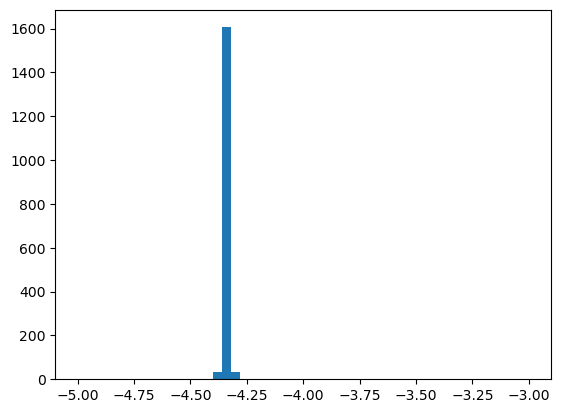

In [ ]:
plt.hist(G_train, bins = 50, range = (-5,-3))

(array([  0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 135.,   3.,
          2.,   0.,   0.,   0.,   0.,   1.,   1.,   0.,   0.,   2.,   1.,
          0.,   2.,   0.,   0.,   1.,   2.,   0.,   0.,   0.,   0.,   1.,
          0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   1.,
          0.,   1.,   0.,   0.,   0.,   0.]),
 array([-5.  , -4.96, -4.92, -4.88, -4.84, -4.8 , -4.76, -4.72, -4.68,
        -4.64, -4.6 , -4.56, -4.52, -4.48, -4.44, -4.4 , -4.36, -4.32,
        -4.28, -4.24, -4.2 , -4.16, -4.12, -4.08, -4.04, -4.  , -3.96,
        -3.92, -3.88, -3.84, -3.8 , -3.76, -3.72, -3.68, -3.64, -3.6 ,
        -3.56, -3.52, -3.48, -3.44, -3.4 , -3.36, -3.32, -3.28, -3.24,
        -3.2 , -3.16, -3.12, -3.08, -3.04, -3.  ]),
 <BarContainer object of 50 artists>)

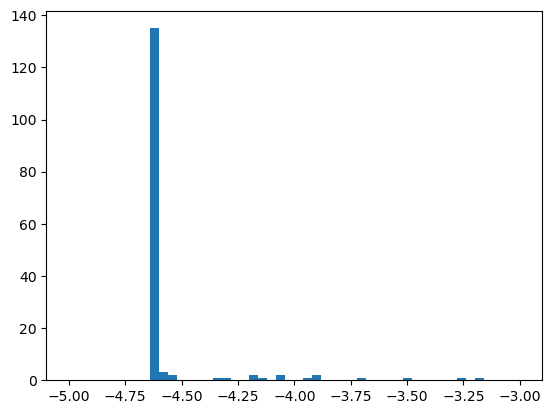

In [ ]:
plt.hist(G_test, bins = 50, range = (-5,-3))